# **Formula 1 Pit Stop Prediction — End-to-End Kaggle Notebook**

**Overview**

This notebook demonstrates a complete machine learning workflow for a Kaggle-style Formula 1 telemetry competition.

**The goal is not only to obtain a good score, but to understand:**

Predict whether a driver will pit in the next lap using race telemetry and strategy-related features.

**The goal is not only to obtain a good score, but to understand:**

* clean structure
* beginner-friendly explanations
* practical competition workflow
* strong documentation

**The goal is not only to obtain a good score, but to understand:**

* how to approach tabular competitions
* how to perform effective EDA
* how to think about leakage and validation
* how to engineer meaningful features
* how to build a robust baseline model1. 

# **Importing Libraries:**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

from lightgbm import LGBMClassifier

# Dataset Loading

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv')

/kaggle/input/competitions/playground-series-s6e5/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e5/train.csv
/kaggle/input/competitions/playground-series-s6e5/test.csv


# Initial Data Inspection

**The first step in every competition should be understanding:**

* dataset shape
* feature types
* missing values
* target distribution
* structure of the data

In [3]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [5]:
train.describe(include = object)

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


In [6]:
print("Dataset Shape : ", train.shape)

print("Info About the Dataset")
train.info()

print("Unique Values In Every Feature")
train.nunique().sort_values()

Dataset Shape :  (439140, 16)
Info About the Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress         

PitStop                        2
PitNextLap                     2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
id                        439140
dtype: int64

* PitStop & PitNextLap have 2 unique values (0 & 1).
* We have 4 years of data available for the races.
* Compund representing the type of the pitch and has 5 different kinds.
* Stint has 7 unique values.

In [7]:
train[['PitStop', 'PitNextLap']].value_counts(normalize=True)

PitStop  PitNextLap
0        0.0           0.698634
         1.0           0.165248
1        0.0           0.102384
         1.0           0.033734
Name: proportion, dtype: float64

* Checking Possible Leakage in "PitStop" but it looked safe.

In [8]:
train = train.drop(columns = ['id'])

cats = train.select_dtypes(include = 'object').columns.to_list()
nums = train.select_dtypes(exclude = "object").columns.to_list()
target = nums.pop()
print(cats, nums, target)

['Driver', 'Compound', 'Race'] ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change'] PitNextLap


# **Understanding the Problem**

**Each row represents:**

A driver's telemetry snapshot during a specific lap in a specific race.

**The target column:**

**PitNextLap**

**is a binary classification target:**

1 → driver will pit next lap
0 → driver will not pit next lap

**This is a:**

* sequential prediction problem
* grouped time-series problem
* binary classification problem

# Target Variable Analysis

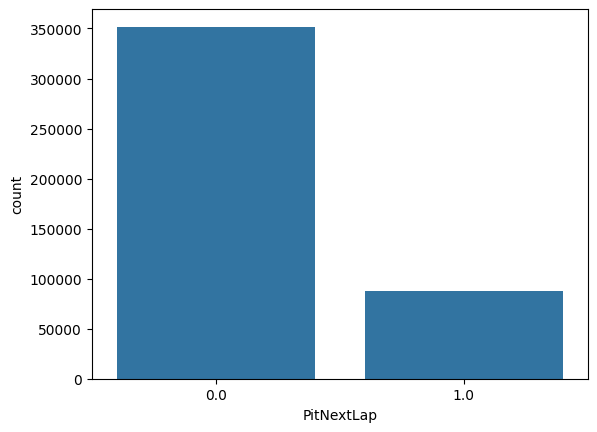

In [9]:
sns.countplot(x = train['PitNextLap'])
plt.show()

In [10]:
class1 = len(train[train['PitNextLap'] == 1])
class0 = len(train[train['PitNextLap'] == 0])

print(f'{class0/train.shape[0] * 100}% is the count where the driver did not pits while {class1/train.shape[0] * 100}% is the count when the driver pits')

80.101789862003% is the count where the driver did not pits while 19.898210137996994% is the count when the driver pits


**There exist a high class imbalance in the target column 'PitNextLap'**. It's 80 Vs 20 as mentioned above.

**This means:**

* accuracy is not a reliable metric
* probability-based metrics are more suitable

**We will therefore use:**

**ROC-AUC**

for evaluation.

# Exploratory Data Analysis

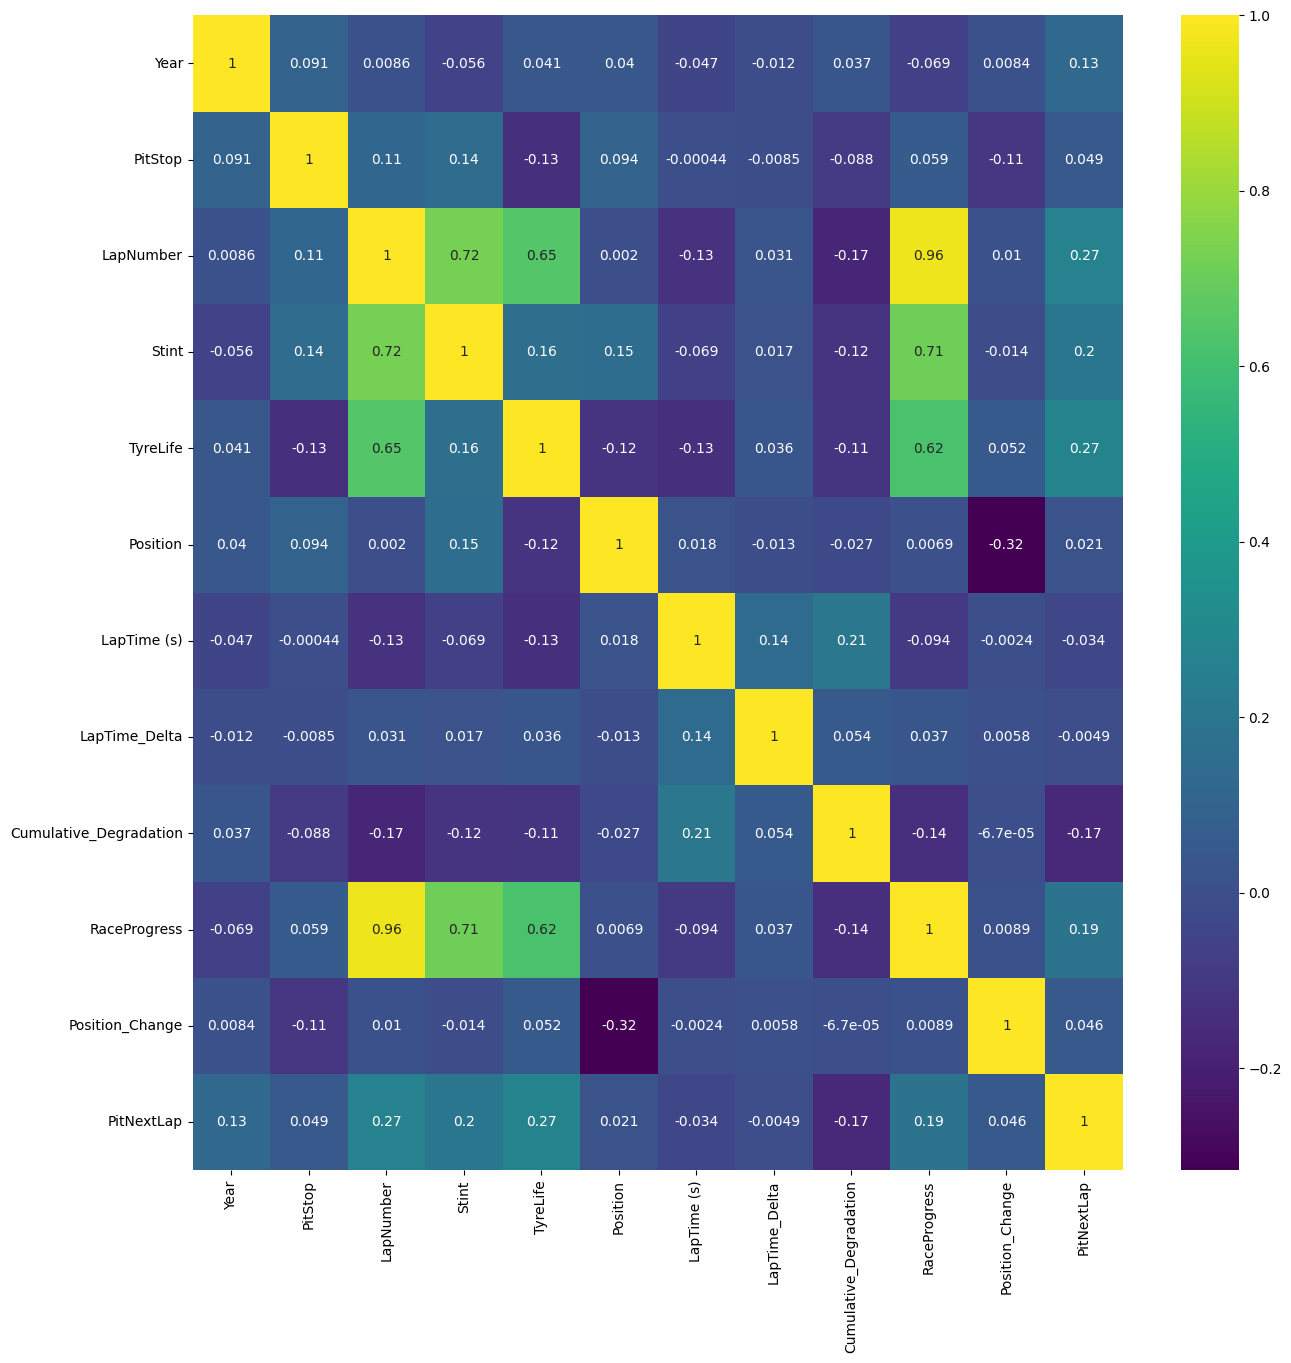

In [11]:
plt.figure(figsize = (15,15))
sns.heatmap(train.corr(numeric_only = True), annot = True, cmap = 'viridis')
plt.show()

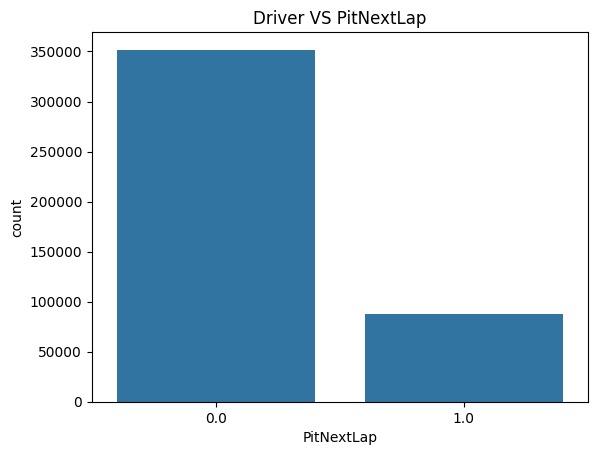

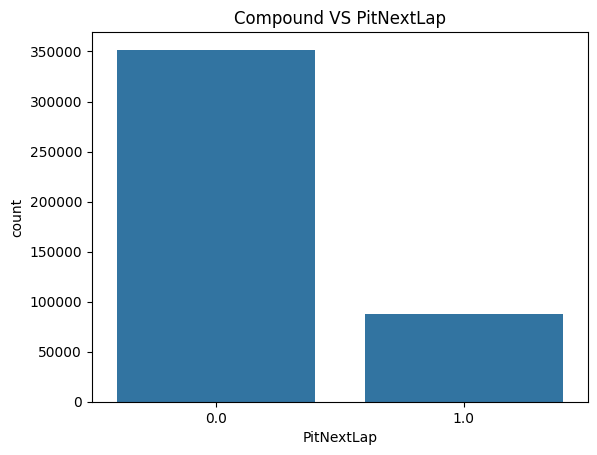

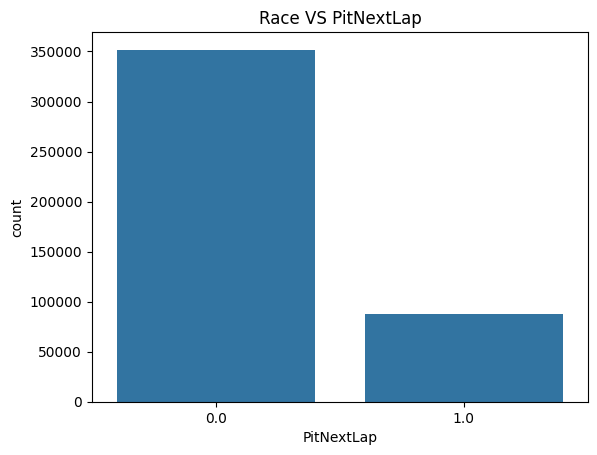

In [12]:
for cat in cats:
    plt.title(f'{cat} VS PitNextLap')
    sns.countplot(data = train, x = 'PitNextLap')
    plt.show()

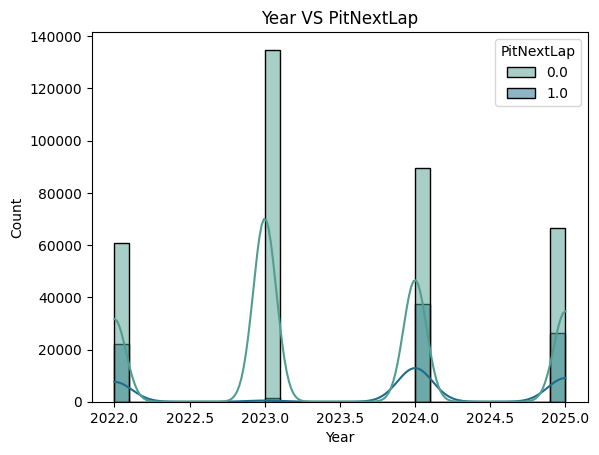

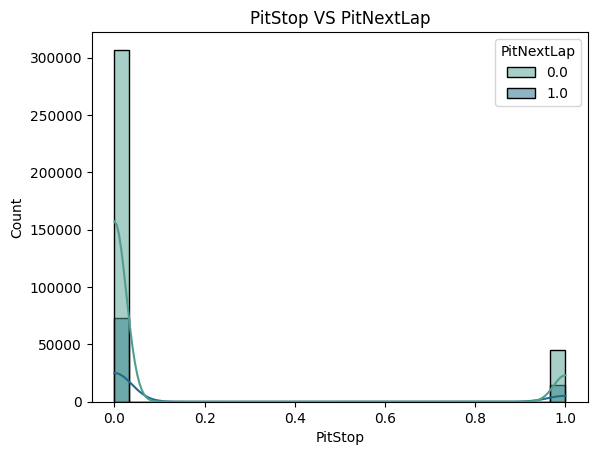

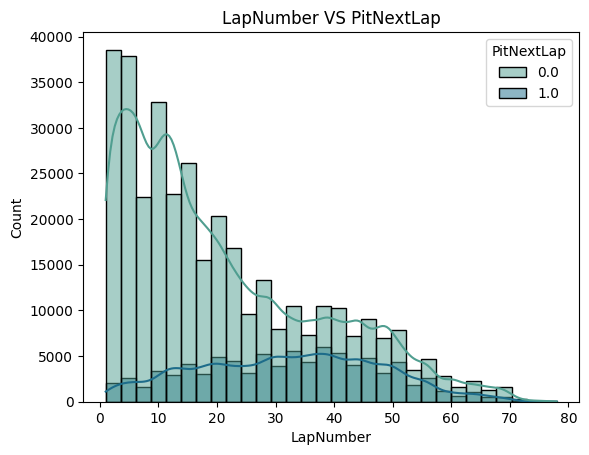

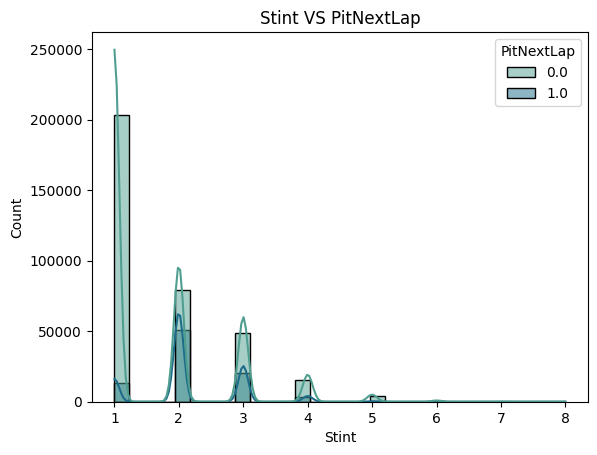

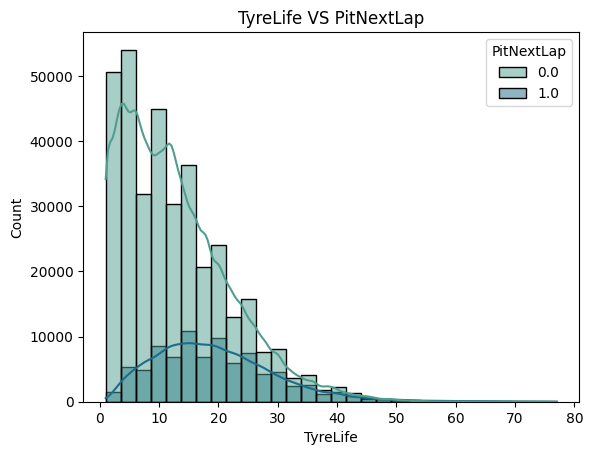

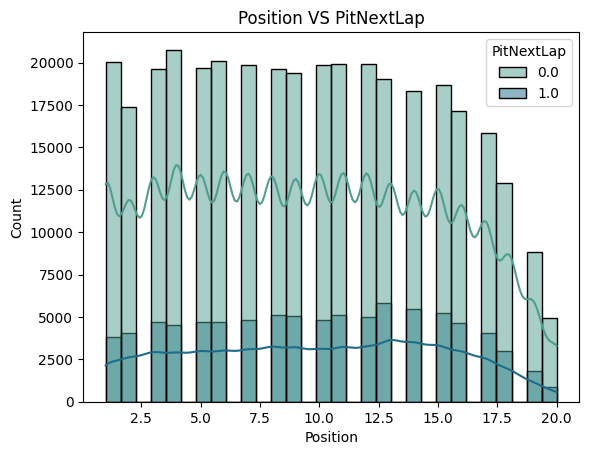

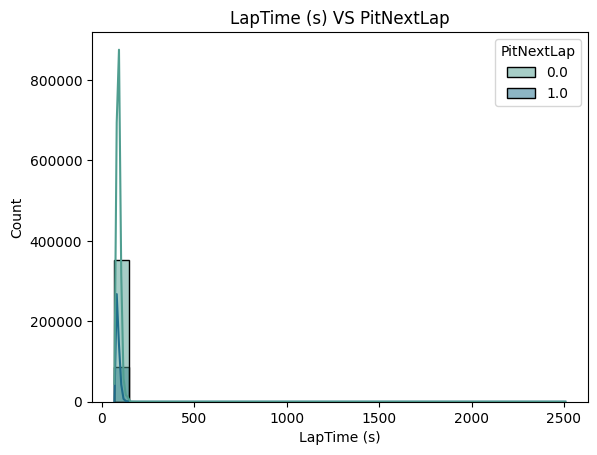

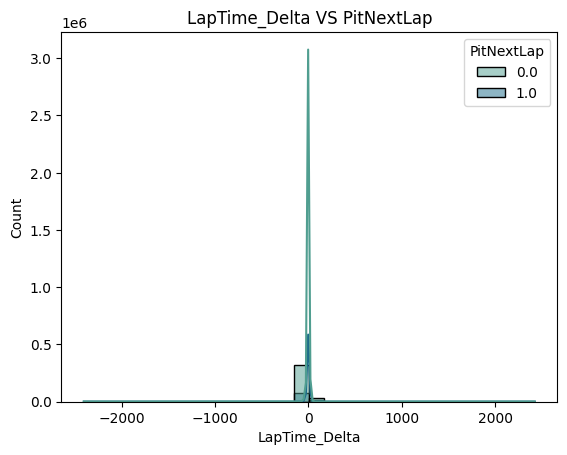

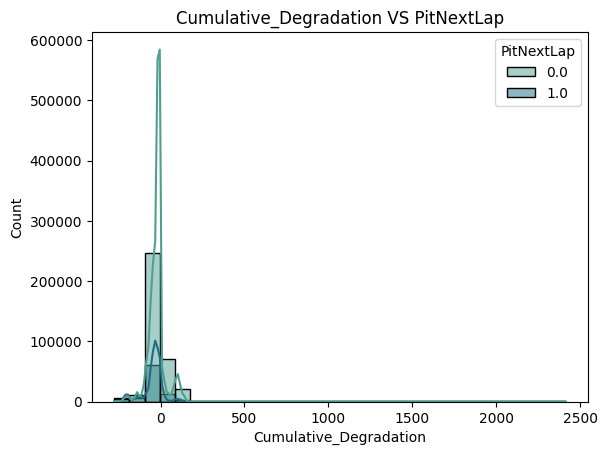

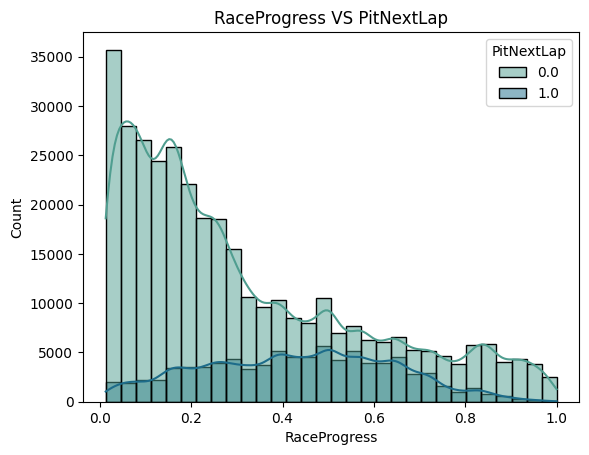

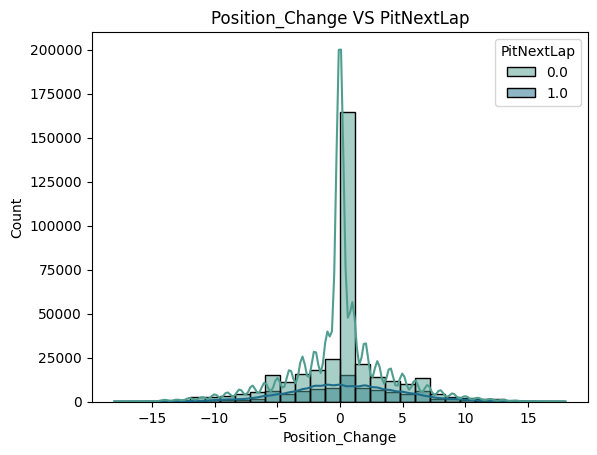

In [13]:
for num in nums:
    plt.title(f'{num} VS PitNextLap')
    sns.histplot(data = train, x = num, hue = 'PitNextLap', bins = 30, palette = 'crest', kde = True)
    plt.show()

# Sequential Structure Analysis

Since this is race telemetry data, order matters.

**We sort the dataset using:**

* Race
* Driver
* LapNumber

In [14]:
train = train.sort_values(['Race', 'Driver', 'LapNumber'])

In [15]:
group_sizes = train.groupby(['Race', 'Driver']).size().describe()

In [16]:
group_sizes.value_counts().sort_index()

1.00000        1
5.00000        1
24.03104       1
25.00000       1
29.38964       1
50.00000       1
103.00000      1
14942.00000    1
Name: count, dtype: int64

In [17]:
train.groupby(['Race', 'Driver'])['LapNumber'].agg(['min', 'max', 'nunique']).head(50)

min  max  nunique
Race                 Driver                   
Abu Dhabi Grand Prix ALB       1   61       32
                     ALE       1   57       39
                     ALG       1   58       36
                     ALO       1   64       34
                     AND       1   57       40
                     ANT       6   45       13
                     ARN       1   54       33
                     BAD       1   56       30
                     BAR       1   58       41
                     BAT       1   57       32
                     BEA       2   55       12
                     BEL       2   57       35
                     BER       1   55       29
                     BIA       1   58       33
                     BOR       4   47       12
                     BOT       2   55       21
                     BRA       1   57       35
                     BRU       1   57       37
                     BUE       1   58       35
                     BUT       1   57       39
                     CAN       1   57       32
                     CAR       1   57       32
                     CEL       1   52       33
                     CHI       1   58       42
                     COL       1   46       22
                     COU       1   58       32
                     D001      1   55       34
                     D002      1   55       31
                     D003      1   57       34
                     D004      1   56       35
                     D005      1   57       38
                     D006      1   56       34
                     D007      1   54       31
                     D008      1   55       30
                     D009      1   54       35
                     D010      1   56       32
                     D011      1   55       29
                     D012      1   56       39
                     D013      1   56       34
                     D014      1   56       35
                     D015      2   55       36
                     D016      1   57       37
                     D017      1   56       37
                     D018      1   56       38
                     D019      1   56       36
                     D020      1   56       36
                     D021      1   56       30
                     D022      1   55       33
                     D023      1   54       33
                     D024      1   55       29

# Pit Stop Timing Analysis

Here we will be investigating in which laps the pitstop mostly happened.

In [18]:
pit_laps = train[train['PitNextLap'] == 1]

pit_laps['LapNumber'].describe()

count    87381.000000
mean        32.192456
std         15.661481
min          1.000000
25%         20.000000
50%         33.000000
75%         44.000000
max         77.000000
Name: LapNumber, dtype: float64

<Axes: xlabel='LapNumber', ylabel='Count'>

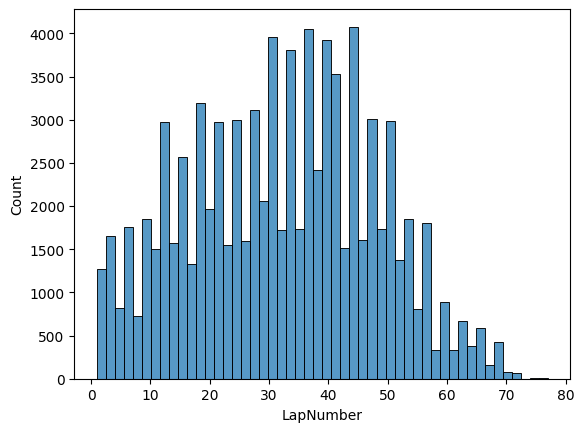

In [19]:
sns.histplot(pit_laps['LapNumber'], bins = 50)

**Key Insight**

Pit stops occur most frequently during the mid-race phase.

**This confirms realistic Formula 1 strategy behavior:**

* tyres degrade over time
* pit windows emerge strategically
* early and late race pits are less frequent

**This immediately suggests:**

**LapNumber**

is a highly predictive feature.

# Correlation Analysis

In [20]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

corrs = train[numeric_cols].corr()['PitNextLap'].sort_values(ascending=False)

corrs.head(15)

PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64

In [21]:
train[['Race', 'Year']].drop_duplicates().sort_values(['Year', 'Race']).head(50)

,Race,Year
309725,Abu Dhabi Grand Prix,2022
383716,Australian Grand Prix,2022
190620,Austrian Grand Prix,2022
126700,Azerbaijan Grand Prix,2022
331565,Bahrain Grand Prix,2022
65477,Belgian Grand Prix,2022
224845,British Grand Prix,2022
67388,Canadian Grand Prix,2022
22067,Chinese Grand Prix,2022
15562,Dutch Grand Prix,2022


Important Learning

**Correlation is useful for:**

* quick signal discovery
* identifying suspicious features

**But**

Correlation does NOT equal feature importance.

Tree models capture nonlinear relationships that correlation cannot detect.

# Feature Engineering

Feature engineering is often the most important part of tabular competitions.

The goal is to transform raw telemetry into strategic race information.

In [22]:
def fe(train):
    train = train.copy()

    max_laps = train.groupby('Race')['LapNumber'].transform('max')
    
    train['RaceProgress'] = train['LapNumber'] / max_laps

    train['RemainingLaps'] = max_laps - train['LapNumber']

    train['TyreLifeRatio'] = train['TyreLife'] / (train['LapNumber'] + 1)

    train['PitIntensity'] = train.groupby(['Race', 'Driver'])['PitStop'].cumsum()

    train['LapTimeDeltaAbs'] = train['LapTime_Delta'].abs()

    cat_cols = ['Driver', 'Compound', 'Race']

    for col in cat_cols:
        train[col] = train[col].astype('category')

    return train

In [23]:
train = fe(train)
test = fe(test)
train.shape

(439140, 19)

# Preparing Training Data

**We removed:**

* Driver
* Race

from training to reduce memorization and improve generalization.

In [24]:
drops = ['PitNextLap', 'Race', 'Driver']
X = train.drop(columns = drops)
y = train['PitNextLap']

# Cross Validation Strategy

Validation strategy is one of the most important parts of Kaggle competitions.

**We use:**

**GroupKFold**

**because:**

* telemetry rows from the same race are highly related
* random splitting would create leakage

In [25]:
gkf = GroupKFold(n_splits=5)

groups = train['Race']

# **LightGBM Baseline Model**

In [26]:
oof_preds = np.zeros(len(train))
scores = []

for fold, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups)):
    
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    
    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]
    
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary',
        random_state=42
    )
    
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric='auc'
    )
    
    preds = model.predict_proba(X_valid)[:, 1]
    
    score = roc_auc_score(y_valid, preds)
    
    oof_preds[valid_idx] = preds
    scores.append(score)
    
    print(f'Fold {fold + 1}: {score:.5f}')

mean_cv = np.mean(scores)
print("Mean Cross Validation Score",mean_cv)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69957, number of negative: 281771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.052745 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1870
[LightGBM] [Info] Number of data points in the train set: 351728, number of used features: 16
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198895 -> initscore=-1.393214
[LightGBM] [Info] Start training from score -1.393214
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

# Feature Importance Analysis

In [27]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance.head(20)

,feature,importance
7,LapTime (s),4372
9,Cumulative_Degradation,3549
13,TyreLifeRatio,2499
15,LapTimeDeltaAbs,2400
8,LapTime_Delta,2187
6,Position,1843
1,Year,1834
11,Position_Change,1650
10,RaceProgress,1616
5,TyreLife,1492


# **Important Insights**

**The strongest features were:**

* LapTime
* Cumulative_Degradation
* TyreLifeRatio
* LapTimeDeltaAbs
* RaceProgress

**This confirms that:**

* tyre degradation
* pace instability
* race progression

are the key drivers behind pit stop decisions.

# **Submission:**

In [28]:
drops = ['id', 'Driver', 'Race']

In [29]:
test.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'RemainingLaps', 'TyreLifeRatio', 'PitIntensity', 'LapTimeDeltaAbs'],
      dtype='object')

In [30]:
test = test.drop(columns=drops)

test_preds = model.predict_proba(test)[:, 1].clip(0,1)

submission = submission.copy()

submission['PitNextLap'] = test_preds

submission.to_csv('submission.csv', index=False)

submission.head()

,id,PitNextLap
0,439140,0.004853
1,439141,0.003306
2,439142,0.002882
3,439143,0.126985
4,439144,0.750831


# **Key Learning Outcomes**

**1. EDA is not just visualization**

EDA should validate assumptions about:

* structure
* leakage
* temporal behavior
* grouping logic

**2. Validation strategy matters enormously**

Bad validation can produce misleading leaderboard performance.

Group-aware splitting is essential for telemetry-style datasets.

**3. Feature engineering drives tabular performance**

Simple, meaningful features often outperform complex modeling.

**4. Correlation is not feature importance**

Tree models can learn nonlinear relationships missed by correlation analysis.

Possible Improvements

**Future improvements may include:**

* CatBoost comparison
* target encoding
* probability calibration
* advanced sequential features
* Optuna hyperparameter tuning
* ensemble modeling
* Make the predictions time-series using years.